# **Housing - Previsão de valores de imóveis com SVR**
### Matheus Luiz de Oliveira

O dataset reúne informações de 20.640 regiões da Califórnia. Vamos usar renda, localização, idade dos imóveis e outras características para prever `median_house_value`, o valor mediano dos imóveis de cada região. O objetivo da atividade é atingir R² maior que 0,65 no teste com SVR.

Fonte: https://www.kaggle.com/datasets/kathuman/housing

# 1 - Import das bibliotecas: bibliotecas usadas para analisar os dados e criar o modelo.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# 2 - Import do dataset: carregamento do arquivo com os dados dos imóveis.

In [2]:
data = pd.read_csv('/kaggle/input/datasets/kathuman/housing/housing.csv')
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 3 - Avaliação do banco de dados: conferência das dimensões, tipos e valores do dataset.

In [3]:
print('Quantidade de linhas:', data.shape[0])
print('Quantidade de colunas:', data.shape[1])
data.info()

Quantidade de linhas: 20640
Quantidade de colunas: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
print('Valores ausentes:')
print(data.isnull().sum())
print('Registros duplicados:', data.duplicated().sum())

Valores ausentes:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Registros duplicados: 0


# 3.1 - Distribuição dos valores: quantidade de regiões em cada faixa de preço.

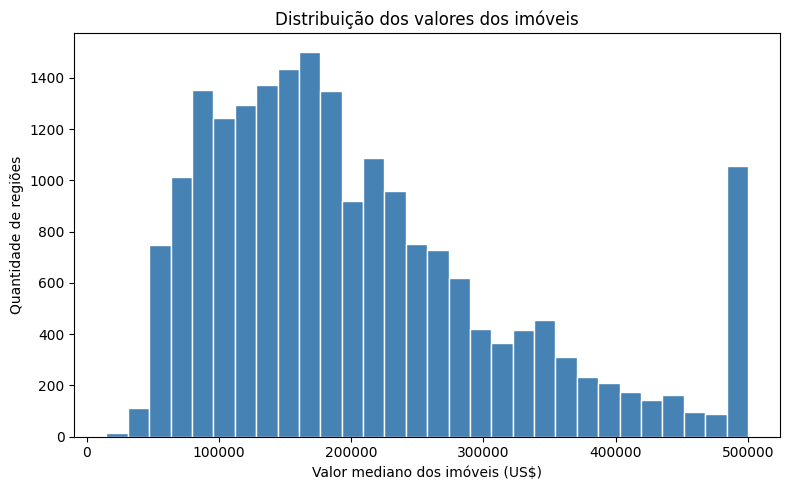

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(data['median_house_value'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Valor mediano dos imóveis (US$)')
plt.ylabel('Quantidade de regiões')
plt.title('Distribuição dos valores dos imóveis')
plt.tight_layout()
plt.show()

# 3.2 - Boxplots: identificação de possíveis valores extremos nas principais variáveis.

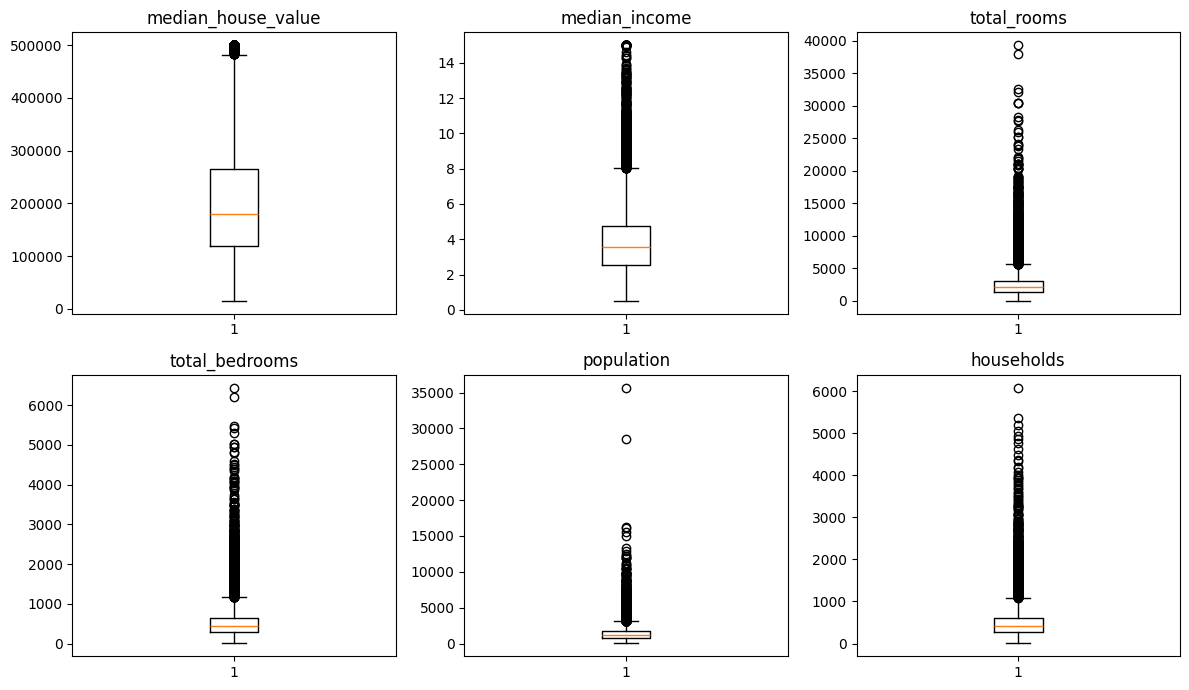

In [7]:
variaveis_boxplot = ['median_house_value', 'median_income', 'total_rooms',
                     'total_bedrooms', 'population', 'households']
fig, eixos = plt.subplots(2, 3, figsize=(12, 7))
for eixo, coluna in zip(eixos.flat, variaveis_boxplot):
    eixo.boxplot(data[coluna].dropna())
    eixo.set_title(coluna)
plt.tight_layout()
plt.show()

# 3.3 - Correlação: comparação das relações entre as variáveis numéricas e o preço.

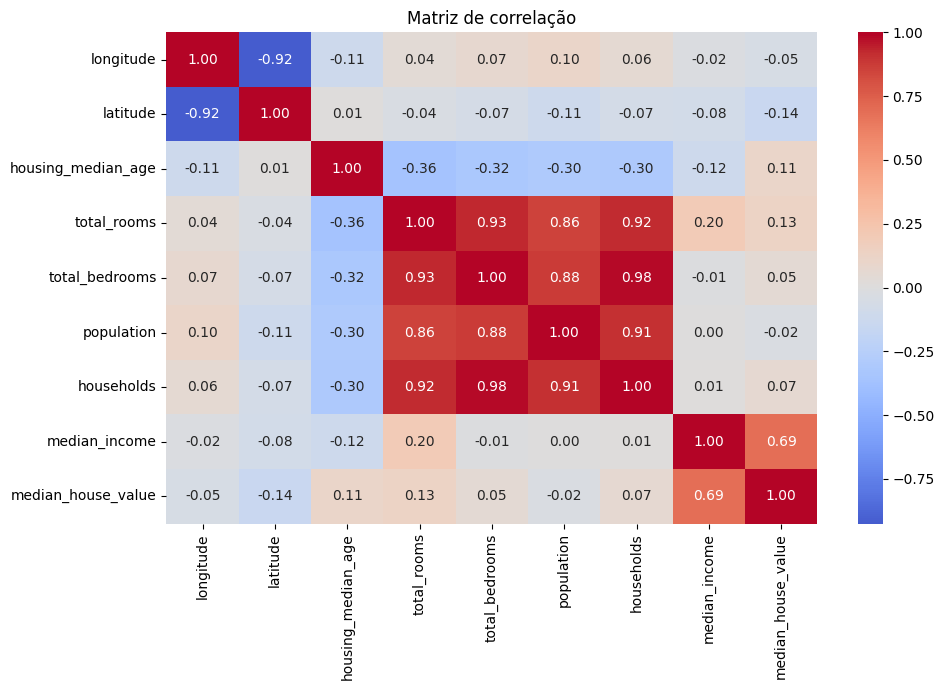

Correlação com o valor dos imóveis:
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [8]:
correlacao = data.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()
print('Correlação com o valor dos imóveis:')
print(correlacao['median_house_value'].drop('median_house_value').sort_values(ascending=False))

# 4 - Dados faltantes: definição do tratamento dos valores vazios e duplicados.

In [9]:
print(data.isnull().sum())
print('Percentual ausente em total_bedrooms:',
      round(data['total_bedrooms'].isnull().mean() * 100, 2), '%')
print('Duplicados:', data.duplicated().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Percentual ausente em total_bedrooms: 1.0 %
Duplicados: 0


# 4.1 - Identificação dos outliers: contagem e percentual pelo método IQR.

In [10]:
resumo_outliers = []
for coluna in data.select_dtypes(include='number').columns:
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = data.loc[(data[coluna] < limite_inferior) |
                        (data[coluna] > limite_superior), coluna]
    resumo_outliers.append({
        'Variável': coluna,
        'Quantidade': len(outliers),
        'Percentual (%)': round(len(outliers) / len(data) * 100, 2),
        'Mínimo da coluna': data[coluna].min(),
        'Máximo da coluna': data[coluna].max(),
        'Mínimo dos outliers': outliers.min(),
        'Máximo dos outliers': outliers.max(),
        'Limite inferior': limite_inferior,
        'Limite superior': limite_superior
    })
outliers_df = pd.DataFrame(resumo_outliers)
outliers_df.round(2)

,Variável,Quantidade,Percentual (%),Mínimo da coluna,Máximo da coluna,Mínimo dos outliers,Máximo dos outliers,Limite inferior,Limite superior
0,longitude,0,0.00,-124.35,-114.31,NaN,NaN,-127.48,-112.33
1,latitude,0,0.00,32.54,41.95,NaN,NaN,28.26,43.38
2,housing_median_age,0,0.00,1.00,52.00,NaN,NaN,-10.50,65.50
3,total_rooms,1287,6.24,2.00,39320.00,5699.00,39320.0,-1102.62,5698.38
4,total_bedrooms,1271,6.16,1.00,6445.00,1174.00,6445.0,-230.50,1173.50
5,population,1196,5.79,3.00,35682.00,3134.00,35682.0,-620.00,3132.00
6,households,1220,5.91,1.00,6082.00,1093.00,6082.0,-207.50,1092.50
7,median_income,681,3.30,0.50,15.00,8.01,15.0,-0.71,8.01
8,median_house_value,1071,5.19,14999.00,500001.00,482700.00,500001.0,-98087.50,482412.50


# 5 - Encoding: transformação da proximidade do oceano em colunas numéricas.

In [11]:
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']
X = pd.get_dummies(X, columns=['ocean_proximity'], dtype=int)
print('Colunas usadas pelo modelo:', X.columns.tolist())
X.head()

Colunas usadas pelo modelo: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,0,1,0


# 6 - Divisão dos dados de teste e treino: separação de 80% para treino e 20% para teste.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (16512, 13)
Teste: (4128, 13)


# 6.1 - Comparação dos tratamentos: avaliação dos dados sem preenchimento, com mediana e com limites de outliers.

In [13]:
treino_completo = X_train.notnull().all(axis=1)
teste_completo = X_test.notnull().all(axis=1)
X_test_comparacao = X_test.loc[teste_completo]
y_test_comparacao = y_test.loc[teste_completo]

modelo_sem_tratamento = SVR()
modelo_sem_tratamento.fit(X_train.loc[treino_completo], y_train.loc[treino_completo])
pred_sem_tratamento = modelo_sem_tratamento.predict(X_test_comparacao)

modelo_mediana = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', SVR())
])
modelo_mediana.fit(X_train, y_train)
pred_mediana = modelo_mediana.predict(X_test_comparacao)

colunas_outliers = ['total_rooms', 'total_bedrooms', 'population', 'households']
Q1 = X_train[colunas_outliers].quantile(0.25)
Q3 = X_train[colunas_outliers].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
X_train_limites = X_train.copy()
X_test_limites = X_test.copy()
X_train_limites[colunas_outliers] = X_train[colunas_outliers].clip(
    lower=limite_inferior, upper=limite_superior, axis=1)
X_test_limites[colunas_outliers] = X_test[colunas_outliers].clip(
    lower=limite_inferior, upper=limite_superior, axis=1)

print('Valores limitados no treino:')
print(((X_train[colunas_outliers] < limite_inferior) |
       (X_train[colunas_outliers] > limite_superior)).sum())

modelo_outliers = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', SVR())
])
modelo_outliers.fit(X_train_limites, y_train)
pred_outliers = modelo_outliers.predict(X_test_limites.loc[teste_completo])

comparacao = [
    {'Modelo': 'Sem preenchimento - linhas completas', 'R²': r2_score(y_test_comparacao, pred_sem_tratamento)},
    {'Modelo': 'Preenchimento pela mediana', 'R²': r2_score(y_test_comparacao, pred_mediana)},
    {'Modelo': 'Mediana + limites de outliers', 'R²': r2_score(y_test_comparacao, pred_outliers)}
]
print('Registros no teste comum:', len(y_test_comparacao))
pd.DataFrame(comparacao).round(4)

Valores limitados no treino:
total_rooms       1046
total_bedrooms    1041
population         955
households         977
dtype: int64
Registros no teste comum: 3921


,Modelo,R²
0,Sem preenchimento - linhas completas,-0.0485
1,Preenchimento pela mediana,-0.0485
2,Mediana + limites de outliers,-0.0480


# 6.2 - Padronização e modelo inicial: ajuste da escala para treinar o SVR.

In [14]:
y_train_escala = y_train / 100000

model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', SVR())
])
model_pipeline.fit(X_train, y_train_escala)
y_pred_inicial = model_pipeline.predict(X_test) * 100000
r2_inicial = r2_score(y_test, y_pred_inicial)
print(f'R² inicial com ajuste das escalas: {r2_inicial:.4f}')

comparacao.append({
    'Modelo': 'Mediana + padronização + preço em 100 mil',
    'R²': r2_score(y_test_comparacao,
                   model_pipeline.predict(X_test_comparacao) * 100000)
})

R² inicial com ajuste das escalas: 0.7437


# 6.3 - Teste dos kernels: comparação entre linear, RBF e polinomial.

In [15]:
resultados_kernels = []
for kernel in ['linear', 'rbf', 'poly']:
    modelo = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', SVR(kernel=kernel, C=1, epsilon=0.1))
    ])
    modelo.fit(X_train, y_train_escala)
    previsao = modelo.predict(X_test) * 100000
    resultados_kernels.append({
        'Kernel': kernel, 'C': 1, 'Epsilon': 0.1,
        'R² no teste': r2_score(y_test, previsao)
    })
    print(kernel, 'R²:', round(r2_score(y_test, previsao), 4))
kernels_df = pd.DataFrame(resultados_kernels)
kernels_df

linear R²: 0.6108
rbf R²: 0.7437
poly R²: 0.6527


,Kernel,C,Epsilon,R² no teste
0,linear,1,0.1,0.610843
1,rbf,1,0.1,0.743679
2,poly,1,0.1,0.652721


# 7 - GridSearchCV: busca da melhor configuração usando validação cruzada no treino.

In [16]:
param_grid = [
    {'regressor__kernel': ['linear'],
     'regressor__C': [0.1, 1],
     'regressor__epsilon': [0.1]},
    {'regressor__kernel': ['poly'],
     'regressor__C': [1],
     'regressor__epsilon': [0.1]},
    {'regressor__kernel': ['rbf'],
     'regressor__C': [1, 10],
     'regressor__epsilon': [0.05, 0.1],
     'regressor__gamma': ['scale', 0.1]}
]
grid_search = GridSearchCV(
    model_pipeline, param_grid, cv=5, scoring='r2', verbose=0, n_jobs=-1
)
grid_search.fit(X_train, y_train_escala)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_
print('Melhores parâmetros:', best_params)
print(f'R² médio na validação cruzada: {best_score:.4f}')

resultados_grid = pd.DataFrame(grid_search.cv_results_)
resultados_grid[['params', 'mean_test_score', 'std_test_score']].sort_values(
    'mean_test_score', ascending=False)

Melhores parâmetros: {'regressor__C': 10, 'regressor__epsilon': 0.1, 'regressor__gamma': 0.1, 'regressor__kernel': 'rbf'}
R² médio na validação cruzada: 0.7806


,params,mean_test_score,std_test_score
10,"{'regressor__C': 10, 'regressor__epsilon': 0.1...",0.780560,0.006083
8,"{'regressor__C': 10, 'regressor__epsilon': 0.0...",0.780065,0.006186
9,"{'regressor__C': 10, 'regressor__epsilon': 0.1...",0.777554,0.005573
7,"{'regressor__C': 10, 'regressor__epsilon': 0.0...",0.776732,0.005685
6,"{'regressor__C': 1, 'regressor__epsilon': 0.1,...",0.760704,0.005957
4,"{'regressor__C': 1, 'regressor__epsilon': 0.05...",0.760124,0.006035
5,"{'regressor__C': 1, 'regressor__epsilon': 0.1,...",0.755339,0.005782
3,"{'regressor__C': 1, 'regressor__epsilon': 0.05...",0.755035,0.005908
1,"{'regressor__C': 1, 'regressor__epsilon': 0.1,...",0.635924,0.008223
0,"{'regressor__C': 0.1, 'regressor__epsilon': 0....",0.635825,0.008125


# 8 - Treino do modelo com teste: avaliação final com R², MAE e RMSE.

In [17]:
y_pred = best_model.predict(X_test) * 100000
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R² no teste: {r2:.4f}')
print(f'MAE: US$ {mae:,.2f}')
print(f'RMSE: US$ {rmse:,.2f}')
print('Registros avaliados:', len(y_test))
print('Atingiu R² maior que 0,65?', r2 > 0.65)

results_df = pd.DataFrame({'Atual': y_test, 'Previsto': y_pred}, index=X_test.index)
results_df.head().round(2)

R² no teste: 0.7711
MAE: US$ 35,931.63
RMSE: US$ 54,764.04
Registros avaliados: 4128
Atingiu R² maior que 0,65? True


,Atual,Previsto
20046,47700.0,47067.94
3024,45800.0,90575.67
15663,500001.0,323060.77
20484,218600.0,236202.31
9814,278000.0,255836.55


# 8.1 - Exemplos de previsão: comparação de três valores reais com as previsões.

In [18]:
for i in range(3):
    sample_data = X_test.iloc[[i]]
    prediction = best_model.predict(sample_data)[0] * 100000
    real = y_test.iloc[i]
    print(f'Exemplo {i + 1}: real = US$ {real:,.2f}, previsto = US$ {prediction:,.2f}')

Exemplo 1: real = US$ 47,700.00, previsto = US$ 47,067.94
Exemplo 2: real = US$ 45,800.00, previsto = US$ 90,575.67
Exemplo 3: real = US$ 500,001.00, previsto = US$ 323,060.77


# 8.2 - Comparação dos experimentos: registro dos tratamentos e configurações testados.

In [19]:
comparacao.append({
    'Modelo': 'Dados mantidos + escalas + GridSearchCV',
    'R²': r2_score(y_test_comparacao,
                   best_model.predict(X_test_comparacao) * 100000)
})
comparacao_df = pd.DataFrame(comparacao)
print('Comparação dos tratamentos nas mesmas linhas completas do teste:')
print(comparacao_df.round(4).to_string(index=False))

experimentos = [
    {'Experimento': 'Modelo inicial', 'Tratamento': 'Mediana + escalas',
     'Kernel': 'rbf', 'C': 1, 'Epsilon': 0.1, 'Gamma': 'scale', 'R²': r2_inicial}
]
for resultado in resultados_kernels:
    experimentos.append({
        'Experimento': 'Comparação de kernel', 'Tratamento': 'Mediana + escalas',
        'Kernel': resultado['Kernel'], 'C': 1, 'Epsilon': 0.1,
        'Gamma': 'scale', 'R²': resultado['R² no teste']
    })
experimentos.append({
    'Experimento': 'GridSearchCV', 'Tratamento': 'Mediana + escalas + busca',
    'Kernel': best_params['regressor__kernel'], 'C': best_params['regressor__C'],
    'Epsilon': best_params['regressor__epsilon'],
    'Gamma': best_params.get('regressor__gamma', 'scale'), 'R²': r2
})
experimentos_df = pd.DataFrame(experimentos)
print('Experimentos no teste completo, com 4.128 registros:')
print(experimentos_df.round(4).to_string(index=False))

Comparação dos tratamentos nas mesmas linhas completas do teste:
                                   Modelo      R²
     Sem preenchimento - linhas completas -0.0485
               Preenchimento pela mediana -0.0485
            Mediana + limites de outliers -0.0480
Mediana + padronização + preço em 100 mil  0.7483
  Dados mantidos + escalas + GridSearchCV  0.7759
Experimentos no teste completo, com 4.128 registros:
         Experimento                Tratamento Kernel  C  Epsilon Gamma     R²
      Modelo inicial         Mediana + escalas    rbf  1      0.1 scale 0.7437
Comparação de kernel         Mediana + escalas linear  1      0.1 scale 0.6108
Comparação de kernel         Mediana + escalas    rbf  1      0.1 scale 0.7437
Comparação de kernel         Mediana + escalas   poly  1      0.1 scale 0.6527
        GridSearchCV Mediana + escalas + busca    rbf 10      0.1   0.1 0.7711


# 9 - Valores reais e previstos: visualização dos resultados do modelo final.

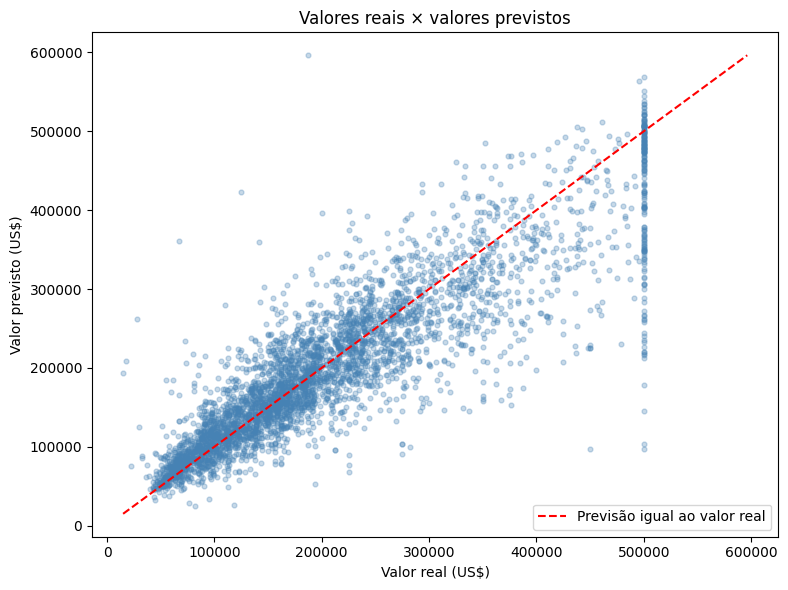

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue')
valor_minimo = min(y_test.min(), y_pred.min())
valor_maximo = max(y_test.max(), y_pred.max())
plt.plot([valor_minimo, valor_maximo], [valor_minimo, valor_maximo],
         color='red', linestyle='--', label='Previsão igual ao valor real')
plt.xlabel('Valor real (US$)')
plt.ylabel('Valor previsto (US$)')
plt.title('Valores reais × valores previstos')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusão

### O modelo final apresentou R² de 0.7711 no teste, MAE de US$ 35,931.63 e RMSE de US$ 54,764.04. A meta de R² maior que 0,65 foi atingida. O GridSearchCV selecionou o kernel RBF com C=10, epsilon=0,1 e gamma=0,1, com R² médio de 0.7806 na validação cruzada.

### O maior ganho apareceu no ajuste das escalas das características e do preço. O preenchimento e os limites de outliers, isoladamente, tiveram pouco efeito no SVR padrão. Os outliers foram mantidos no modelo final porque não havia evidência suficiente de erro. As principais dificuldades foram as diferenças de escala, os dados ausentes e o tempo da busca. Para melhorar, poderíamos testar quartos por domicílio e novas faixas de C e gamma, usando validação no treino.